## Overview

This notebook provides a tool to assess whether utility customers can increase their load without overloading their transformer. 

This use case is designed as follows:
  * Enter a meter of interest and the maximum expected increase in load for this meter.
  * Use a REST API to find the transformer above the meter. 
  * Use a REST API to aggregate all loads downstream from the specific transformer.
  * Identify the day with the highest load, plot the existing and expected load during this day, and compare it to the transformer's capacity.
  * Plot a distribution of the expected load with respect to the hours of the day and the months of the year. 
  * Find the number of days and the number of hours per day where the expected load could exceed the transformer's capacity and plot it. 

The results of this tool will help decision-makers assess the need for transformer upgrades and will help avoid potential damage to existing transformers.


For more details about transformer load and how it can be analyzed using Awesense's platform, please refer to the [UC38 - Transformer Load Increase Assessment Tool](https://github.com/Awesense/edm-app-examples/blob/master/use_cases/usecase_descriptions/UC38%20-%20Transformer%20Load%20Increase%20Assessment%20Tool.pdf) document.

It is assumed that the user has been given credentials for accessing the Awesense Sandbox. Otherwise, please contact us at [api@awesense.com](api@awesense.com).

You can find more information about how to use Awesense's REST API in the [access_and_basic_data_retrieval](https://github.com/Awesense/edm-app-examples/blob/master/intro_and_tutorials/rest_api/access_and_basic_data_retrieval.ipynb) notebook.

## Setup 

In [1]:
from datetime import datetime
import getpass
from io import StringIO

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pytz
import requests

pd.set_option("display.max_columns", None)

### Connection

Enter the login credentials provided by Awesense. If you do not have the credentials or have any trouble connecting, please contact api@awesense.com.
<span style='color:red'> **Please do NOT store the credentials in the notebook, nor share them with anyone.** </span>

In [ ]:
# Enter the REST server origin or hostname (optionally without "https://")
server_hostname = getpass.getpass(prompt="REST server address: ")
# Ensure that the server address does not specify plaintext HTTP
assert (
    server_hostname.startswith("http://") == False
), "Server address uses https:// for secure communications, not http://"

# Support the case where the specified address already included `https://`, otherwise add it
if server_hostname.startswith("https://"):
    server_origin = server_hostname
else:
    server_origin = f"https://{server_hostname}"

REST server address:  ········


In [ ]:
# Enter the username that you use to log into the server
server_user_name = getpass.getpass(prompt="Username: ")

Username:  ········


In [ ]:
# Enter the password that you use to log into the server
server_password = getpass.getpass(prompt="Password: ")

Password:  ········


In [5]:
# This auth tuple can be passed to `requests` functions as the `auth` argument.
# (An HTTP Basic Authentication header will be generated and used automatically)
auth = (server_user_name, server_password)

---

## Use Case - Transformer Increase Assessment Tool

#### Input Parameters
Input the grid name, the meter_id, and the future additional load. 

In [6]:
# User input for the grid.
grid_id = input("Enter grid ID: ")  # e.g. North Central Zone

Enter grid ID:  North Central Zone


In [7]:
# Define the grid_id time zone.
if grid_id == "awefice":
    time_zone = "America/Vancouver"
elif grid_id == "North Central Zone":
    time_zone = "America/New_York"

In [8]:
# User input for the meter.
meter_id = input("Enter meter ID: ")  # e.g. 13Y68ZB or 16A3Y52-1

Enter meter ID:  13Y68ZB


In [9]:
# Additional load required by a customer in kW.
additional_load = input("Enter required load in kW: ")  # e.g. 6.0

Enter required load in kW:  6.0


In [ ]:
# Define the start and end dates for the analysis and convert them to UTC using the appropriate format.
local_start_and_end_dates = ["2023-01-01 00:00:00", "2023-12-31 23:00:00"]

converted_dates = []

local_timezone_obj = pytz.timezone(time_zone)

for date_str in local_start_and_end_dates:
    local_date_obj = datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S")
    localized_date = local_timezone_obj.localize(local_date_obj)
    utc_date = localized_date.astimezone(pytz.utc)
    formatted_utc_date = utc_date.strftime("%Y-%m-%dT%H:%M:%S.%f") + "Z"
    converted_dates.append(formatted_utc_date)

print(converted_dates)

['2023-01-01T05:00:00.000000Z', '2024-01-01T04:00:00.000000Z']


### Data
#### Transformers Information

In [11]:
# Use the tracing endpoint to find the transformer above the `meter_id`.
params = {
    "trace_type": "upstream",
    "output_type": "transformer_download",
    "grid_id": grid_id,
    "grid_element_id": meter_id,
}

response = requests.get(f"{server_origin}/api/v1/grid/trace", auth=auth, params=params)
transformer_above_meter_id = pd.read_csv(StringIO(response.content.decode("utf-8")))

# Get only the transformers with `ML/LV` voltage level.
transformer_above_meter_id = transformer_above_meter_id.loc[
    transformer_above_meter_id["voltage_level"] == "MV/LV"
]
transformer_above_meter_id

,ID,Phases,commission_date,enclosure_id,hvmv_parent_element,installation_type,is_operation_status,label,latitude,load_loss,longitude,maintenance_type,make_model,manufacture_date,mv_feeder,name,no_load_loss,ownership,parent_transformer_id,primary_voltage,rating_kva,secondary_voltage,voltage_level,winding_configuration
0,10193,B,2008-03-29,NaN,NaN,NaN,NaN,13Y68,NaN,1055,NaN,NaN,NaN,2007-01-22,102.0,10193,187,utility,NaN,14000,10.0,NaN,MV/LV,NaN


#### Meter Information

In [ ]:
# Use the trace endpoint to find all the meters downstream of the transformer.
transformer_id = transformer_above_meter_id["ID"].iloc[0]

params = {
    "trace_type": "downstream",
    "output_type": "meter_download",
    "grid_id": grid_id,
    "grid_element_id": transformer_id,
}

response = requests.get(f"{server_origin}/api/v1/grid/trace", auth=auth, params=params)
meters_downstream_of_transformer = pd.read_csv(
    StringIO(response.content.decode("utf-8"))
)
meters_downstream_of_transformer

,ID,Phases,address,business_identifier_id,commission_date,connected_to_lvmv,energy_source,estimated,hvmv_parent_element,interval,is_critical,is_operation_status,label,latitude,longitude,lv_feeder,make_model,maximal_demand,maximal_demand_units,meter_multiplier,meter_number,meter_type,mv_feeder,name,parent_transformer_id,read_type,replacement_cycle,sdp_id,service_drop_type,source_rating_kw,standard_profile_id,tariff_id,type_of_consumer,voltage_level,zone_level_1,zone_level_2,zone_level_3,zone_level_4
0,13Y68,B,12536 Falcatta Dr,2068004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential,LV,NaN,NaN,NaN,NaN
1,13Y68ZB,B,9102 Huguenard Rd,1831308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95040333.0,NaN,L13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential,LV,NaN,NaN,NaN,NaN
2,13Y68-ZC,B,9304 Aboite Center Rd,40008422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14824496.0,NaN,L13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential,LV,NaN,NaN,NaN,NaN


#### Existing Transformer Load

In [ ]:
# Use the `data` endpoint to get the net consumption for each meter downstream of the transformer.
transformer_ts = pd.DataFrame()
for meter_index, row in meters_downstream_of_transformer.iterrows():
    meter_element_id = meters_downstream_of_transformer["ID"][meter_index]

    params = {
        "units": "kWh",
        "group_by": "hour",
        "start": converted_dates[0],
        "end": converted_dates[1],
        "max_points": "200000",
        "timezone": time_zone,
        "export": "false",
    }

    response = requests.get(
        f"{server_origin}/api/v1/grid/{grid_id}/element/{meter_element_id}/data",
        auth=auth,
        params=params,
    )
    ts = pd.json_normalize(response.json())
    ts["meter_id"] = meter_element_id
    transformer_ts = pd.concat([transformer_ts, ts])
transformer_ts

,series,units,meter_id
0,"[{'amount': 1.23, 'period': 3600.0, 'timestamp...",kWh,13Y68
0,"[{'amount': 0.614, 'period': 3600.0, 'timestam...",kWh,13Y68ZB
0,"[{'amount': 1.13, 'period': 3600.0, 'timestamp...",kWh,13Y68-ZC


In [ ]:
# Unpack the meters' time series, aggregate the total hourly load, and rename the 'amount' column.
transformer_aggregate_ts = (
    pd.json_normalize(
        transformer_ts.to_dict("records"),
        record_path="series",
        meta=["units", "meter_id"],
    )
    .groupby(by=["timestamp"])
    .sum()
    .reset_index()[["timestamp", "amount"]]
    .rename(columns={"amount": "total_kWh"})
)

# Convert kWh to kW (Energy to power). Since the energy data is hourly, converting it to average hourly power means dividing the energy values by 1.
transformer_aggregate_ts["power_kW"] = transformer_aggregate_ts["total_kWh"] / 1
transformer_aggregate_ts.drop(columns=["total_kWh"], inplace=True)

transformer_aggregate_ts

,timestamp,power_kW
0,2023-01-01T05:00:00.000000Z,2.974
1,2023-01-01T06:00:00.000000Z,3.309
2,2023-01-01T07:00:00.000000Z,3.199
3,2023-01-01T08:00:00.000000Z,3.283
4,2023-01-01T09:00:00.000000Z,3.361
...,...,...
8753,2023-12-31T23:00:00.000000Z,3.564
8754,2024-01-01T00:00:00.000000Z,3.623
8755,2024-01-01T01:00:00.000000Z,3.034
8756,2024-01-01T02:00:00.000000Z,3.322


In [15]:
# Add a column with the transformer's ID.
transformer_aggregate_ts["transformer_id"] = transformer_id

# Add a column with the transformer's `rating_kva`.
transformer_aggregate_ts["rating_kva"] = transformer_above_meter_id.loc[
    transformer_above_meter_id["ID"] == transformer_id, "rating_kva"
].iloc[0]

# Calculate the transformer's capacity (in kW) based on the transformer's `rating_kva`.
transformer_aggregate_ts["capacity_kW"] = transformer_aggregate_ts["rating_kva"] * 0.98

# Convert the timestamp to a datetime format.
transformer_aggregate_ts["timestamp"] = pd.to_datetime(
    transformer_aggregate_ts["timestamp"]
)

# Localize the timestamp.
transformer_aggregate_ts["timestamp"] = transformer_aggregate_ts[
    "timestamp"
].dt.tz_convert(time_zone)

# Calculate the total future load by adding the additional load.
transformer_aggregate_ts["power_kW_with_additional_load"] = transformer_aggregate_ts[
    "power_kW"
] + float(additional_load)

# Display the time series.
transformer_aggregate_ts.head()

,timestamp,power_kW,transformer_id,rating_kva,capacity_kW,power_kW_with_additional_load
0,2023-01-01 00:00:00-05:00,2.974,10193,10.0,9.8,8.974
1,2023-01-01 01:00:00-05:00,3.309,10193,10.0,9.8,9.309
2,2023-01-01 02:00:00-05:00,3.199,10193,10.0,9.8,9.199
3,2023-01-01 03:00:00-05:00,3.283,10193,10.0,9.8,9.283
4,2023-01-01 04:00:00-05:00,3.361,10193,10.0,9.8,9.361


### Analysis

To properly assess the impact of adding load on a transformer, it's essential to know when this extra load will be applied. Since this is unknown in our case, the additional load will assumed to be present for all hours of the day over the entire period. 

Initially, the analysis will focus on the impact of the additional load on the peak load day and examine whether it causes the load to exceed the transformer's capacity. After that, further analysis will be conducted to explore the distribution of the expected load in relation to the hours of the day and the months of the year and compare it with the transformer's available capacity.

By examining the distribution of the expected load, we can gain further insights into whether exceeding the transformer’s capacity is more likely to occur during certain hours of the day or certain months of the year. This is particularly relevant if the additional load is from an EV charger or a heat pump, where it may be concentrated at specific times.

In [16]:
# Find the date when maximum load occurs.
peak_date = transformer_aggregate_ts.loc[
    transformer_aggregate_ts["power_kW"] == transformer_aggregate_ts["power_kW"].max(),
    "timestamp",
].dt.date.iloc[0]
# Get the time series during the day of maximum consumption.
peak_date_ts = transformer_aggregate_ts.loc[
    transformer_aggregate_ts["timestamp"].dt.date == peak_date
].reset_index()

# Display the results.
peak_date_ts.head()

,index,timestamp,power_kW,transformer_id,rating_kva,capacity_kW,power_kW_with_additional_load
0,4463,2023-07-06 00:00:00-04:00,10.39,10193,10.0,9.8,16.39
1,4464,2023-07-06 01:00:00-04:00,10.11,10193,10.0,9.8,16.11
2,4465,2023-07-06 02:00:00-04:00,9.98,10193,10.0,9.8,15.98
3,4466,2023-07-06 03:00:00-04:00,9.00,10193,10.0,9.8,15.00
4,4467,2023-07-06 04:00:00-04:00,11.56,10193,10.0,9.8,17.56


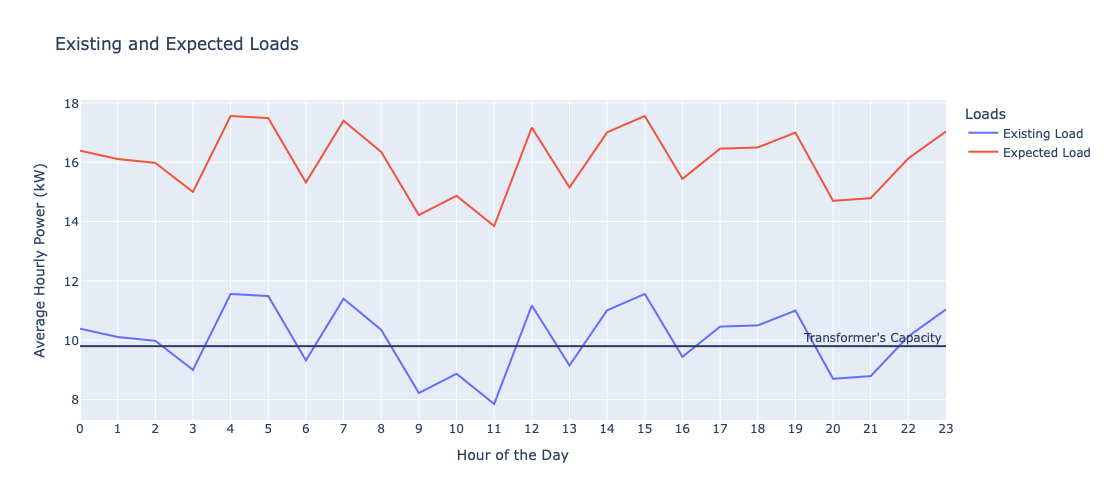

In [ ]:
# Rearrange the data frame to a format with an identifier variable and measured variables. This will allow for simple plotting.
peak_date_ts_for_plot = peak_date_ts.rename(
    columns={
        "power_kW": "Existing Load",
        "power_kW_with_additional_load": "Expected Load",
    }
)
peak_date_ts_for_plot = pd.melt(
    peak_date_ts_for_plot,
    id_vars=["timestamp"],
    value_vars=["Existing Load", "Expected Load"],
    var_name="Loads",
    value_name="Average Hourly Power (kW)",
)

# Plot the existing load, future load, and transformer's capacity during the day when maximum load occurs.
fig = px.line(
    peak_date_ts_for_plot,
    x=peak_date_ts_for_plot["timestamp"].dt.hour,
    y="Average Hourly Power (kW)",
    color="Loads",
    title="Existing and Expected Loads",
    labels={"x": "Hour of the Day"},
)
fig.add_hline(
    y=peak_date_ts["capacity_kW"].unique()[0], annotation_text="Transformer's Capacity"
)

fig.update_layout(height=500, width=1000)
fig.update_xaxes(dtick=1)
fig.show()

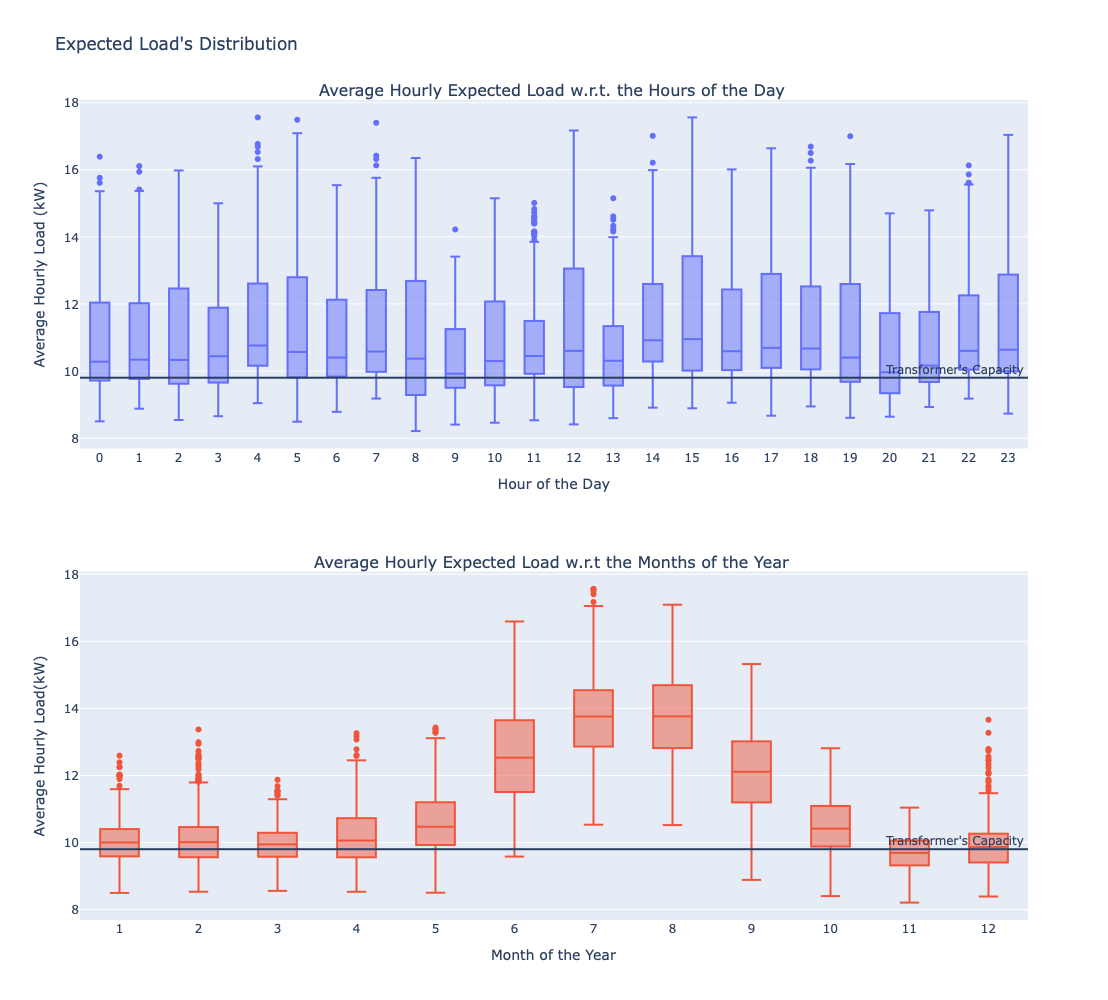

In [18]:
# Plot the distribution of the expected load with respect to the hours of the day and the months of the year.
fig = make_subplots(
    rows=2,
    cols=1,
    vertical_spacing=0.15,
    subplot_titles=(
        "Average Hourly Expected Load w.r.t. the Hours of the Day",
        "Average Hourly Expected Load w.r.t the Months of the Year",
    ),
)

fig.add_trace(
    go.Box(
        x=transformer_aggregate_ts["timestamp"].dt.hour,
        y=transformer_aggregate_ts["power_kW_with_additional_load"],
        showlegend=False,
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Box(
        x=transformer_aggregate_ts["timestamp"].dt.month,
        y=transformer_aggregate_ts["power_kW_with_additional_load"],
        showlegend=False,
    ),
    row=2,
    col=1,
)

fig.update_layout(title="Expected Load's Distribution")
fig.update_xaxes(title_text="Hour of the Day", row=1, col=1)
fig.update_xaxes(title_text="Month of the Year", row=2, col=1)
fig.update_yaxes(title_text="Average Hourly Load (kW)", row=1, col=1)
fig.update_yaxes(title_text="Average Hourly Load(kW)", row=2, col=1)
fig.update_layout(xaxis1=dict(tick0=1, dtick=1))
fig.update_layout(xaxis2=dict(tick0=1, dtick=1))
fig.update_layout(height=1000, width=1000)
fig.add_hline(
    y=peak_date_ts["capacity_kW"].unique()[0], annotation_text="Transformer's Capacity"
)

The number of days when load did not exceed available capacity is: 0 days
The number of days when load did exceed available capacity is: 365 days


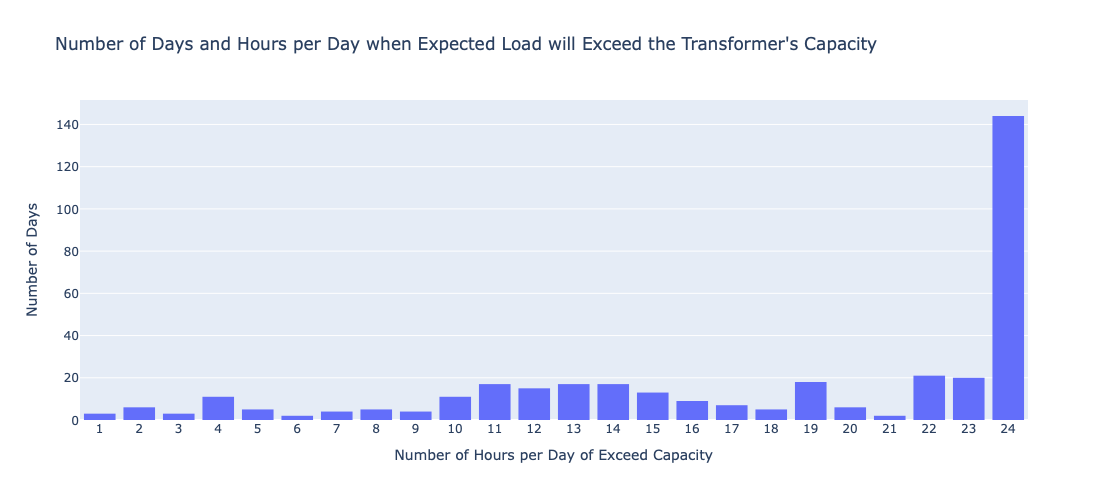

In [ ]:
# Find and display a histogram of the number of days and hours per day where the expected load could exceed the transformer's capacity.
number_of_hours_when_load_exceed_capacity = (
    transformer_aggregate_ts.loc[
        transformer_aggregate_ts["power_kW_with_additional_load"]
        >= transformer_aggregate_ts["capacity_kW"]
    ]
    .groupby(transformer_aggregate_ts["timestamp"].dt.date)
    .count()
)

number_of_days_when_load_exceeded_capacity = len(
    number_of_hours_when_load_exceed_capacity
)
number_of_days_when_load_did_not_exceed_capacity = (
    len(transformer_aggregate_ts.timestamp.dt.date.unique())
    - number_of_days_when_load_exceeded_capacity
)
print(
    f"The number of days when load did not exceed available capacity is: {number_of_days_when_load_did_not_exceed_capacity} days"
)
print(
    f"The number of days when load did exceed available capacity is: {number_of_days_when_load_exceeded_capacity} days"
)


fig = px.histogram(
    number_of_hours_when_load_exceed_capacity,
    x="transformer_id",
    nbins=24,
    labels=dict(transformer_id="Number of Hours per Day of Exceed Capacity"),
    title="Number of Days and Hours per Day when Expected Load will Exceed the Transformer's Capacity",
)
fig.update_layout(yaxis_title_text="Number of Days")
fig.update_layout(bargap=0.2)
fig.update_layout(height=500, width=1000)
fig.update_xaxes(dtick=1)
fig.show()

---